In [1]:
import pandas as pd
import numpy as np

# Load one file to understand the structure
file_path = r'F:\Pipeline Data\pipeline data\Water_13Bar.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print("\nAny missing values:")
print(df.isnull().sum())

Dataset shape: (360, 12001)

Column names:
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80', 'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90', 'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99', 'f100', 'f101', 'f102', 'f103', 'f104', 'f105', 'f106', 'f107', 'f108', 'f109', 'f110', 'f111', 'f112', 'f113', 'f114', 'f115', 'f116', 'f117', 'f118', 'f119', 'f120', 'f121', 'f122', 'f123', 'f124', 'f125', 'f126', 'f127', 'f128', 'f129', 'f130', 'f131', 'f132', 'f133', 

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import pywt

# Load all datasets
data_files = {
    'Water_13Bar': r'F:\Pipeline Data\pipeline data\Water_13Bar.csv',
    'Water_18Bar': r'F:\Pipeline Data\pipeline data\Water_18Bar.csv',
    'Gas_13Bar': r'F:\Pipeline Data\pipeline data\Gas_13Bar.csv',
    'Gas_18Bar': r'F:\Pipeline Data\pipeline data\Gas_18Bar.csv'
}

datasets = {}
for name, path in data_files.items():
    datasets[name] = pd.read_csv(path)
    print(f"{name}: {datasets[name].shape}, Leak samples: {datasets[name]['label'].sum()}")

print("\n=== DATA DISTRIBUTION ===")
for name, df in datasets.items():
    print(f"{name}: No-leak={len(df[df['label']==0])}, Leak={len(df[df['label']==1])}")

Water_13Bar: (360, 12001), Leak samples: 240
Water_18Bar: (360, 12001), Leak samples: 240
Gas_13Bar: (360, 12001), Leak samples: 240
Gas_18Bar: (360, 12001), Leak samples: 240

=== DATA DISTRIBUTION ===
Water_13Bar: No-leak=120, Leak=240
Water_18Bar: No-leak=120, Leak=240
Gas_13Bar: No-leak=120, Leak=240
Gas_18Bar: No-leak=120, Leak=240


✅ Saved: signal_analysis_comprehensive.png


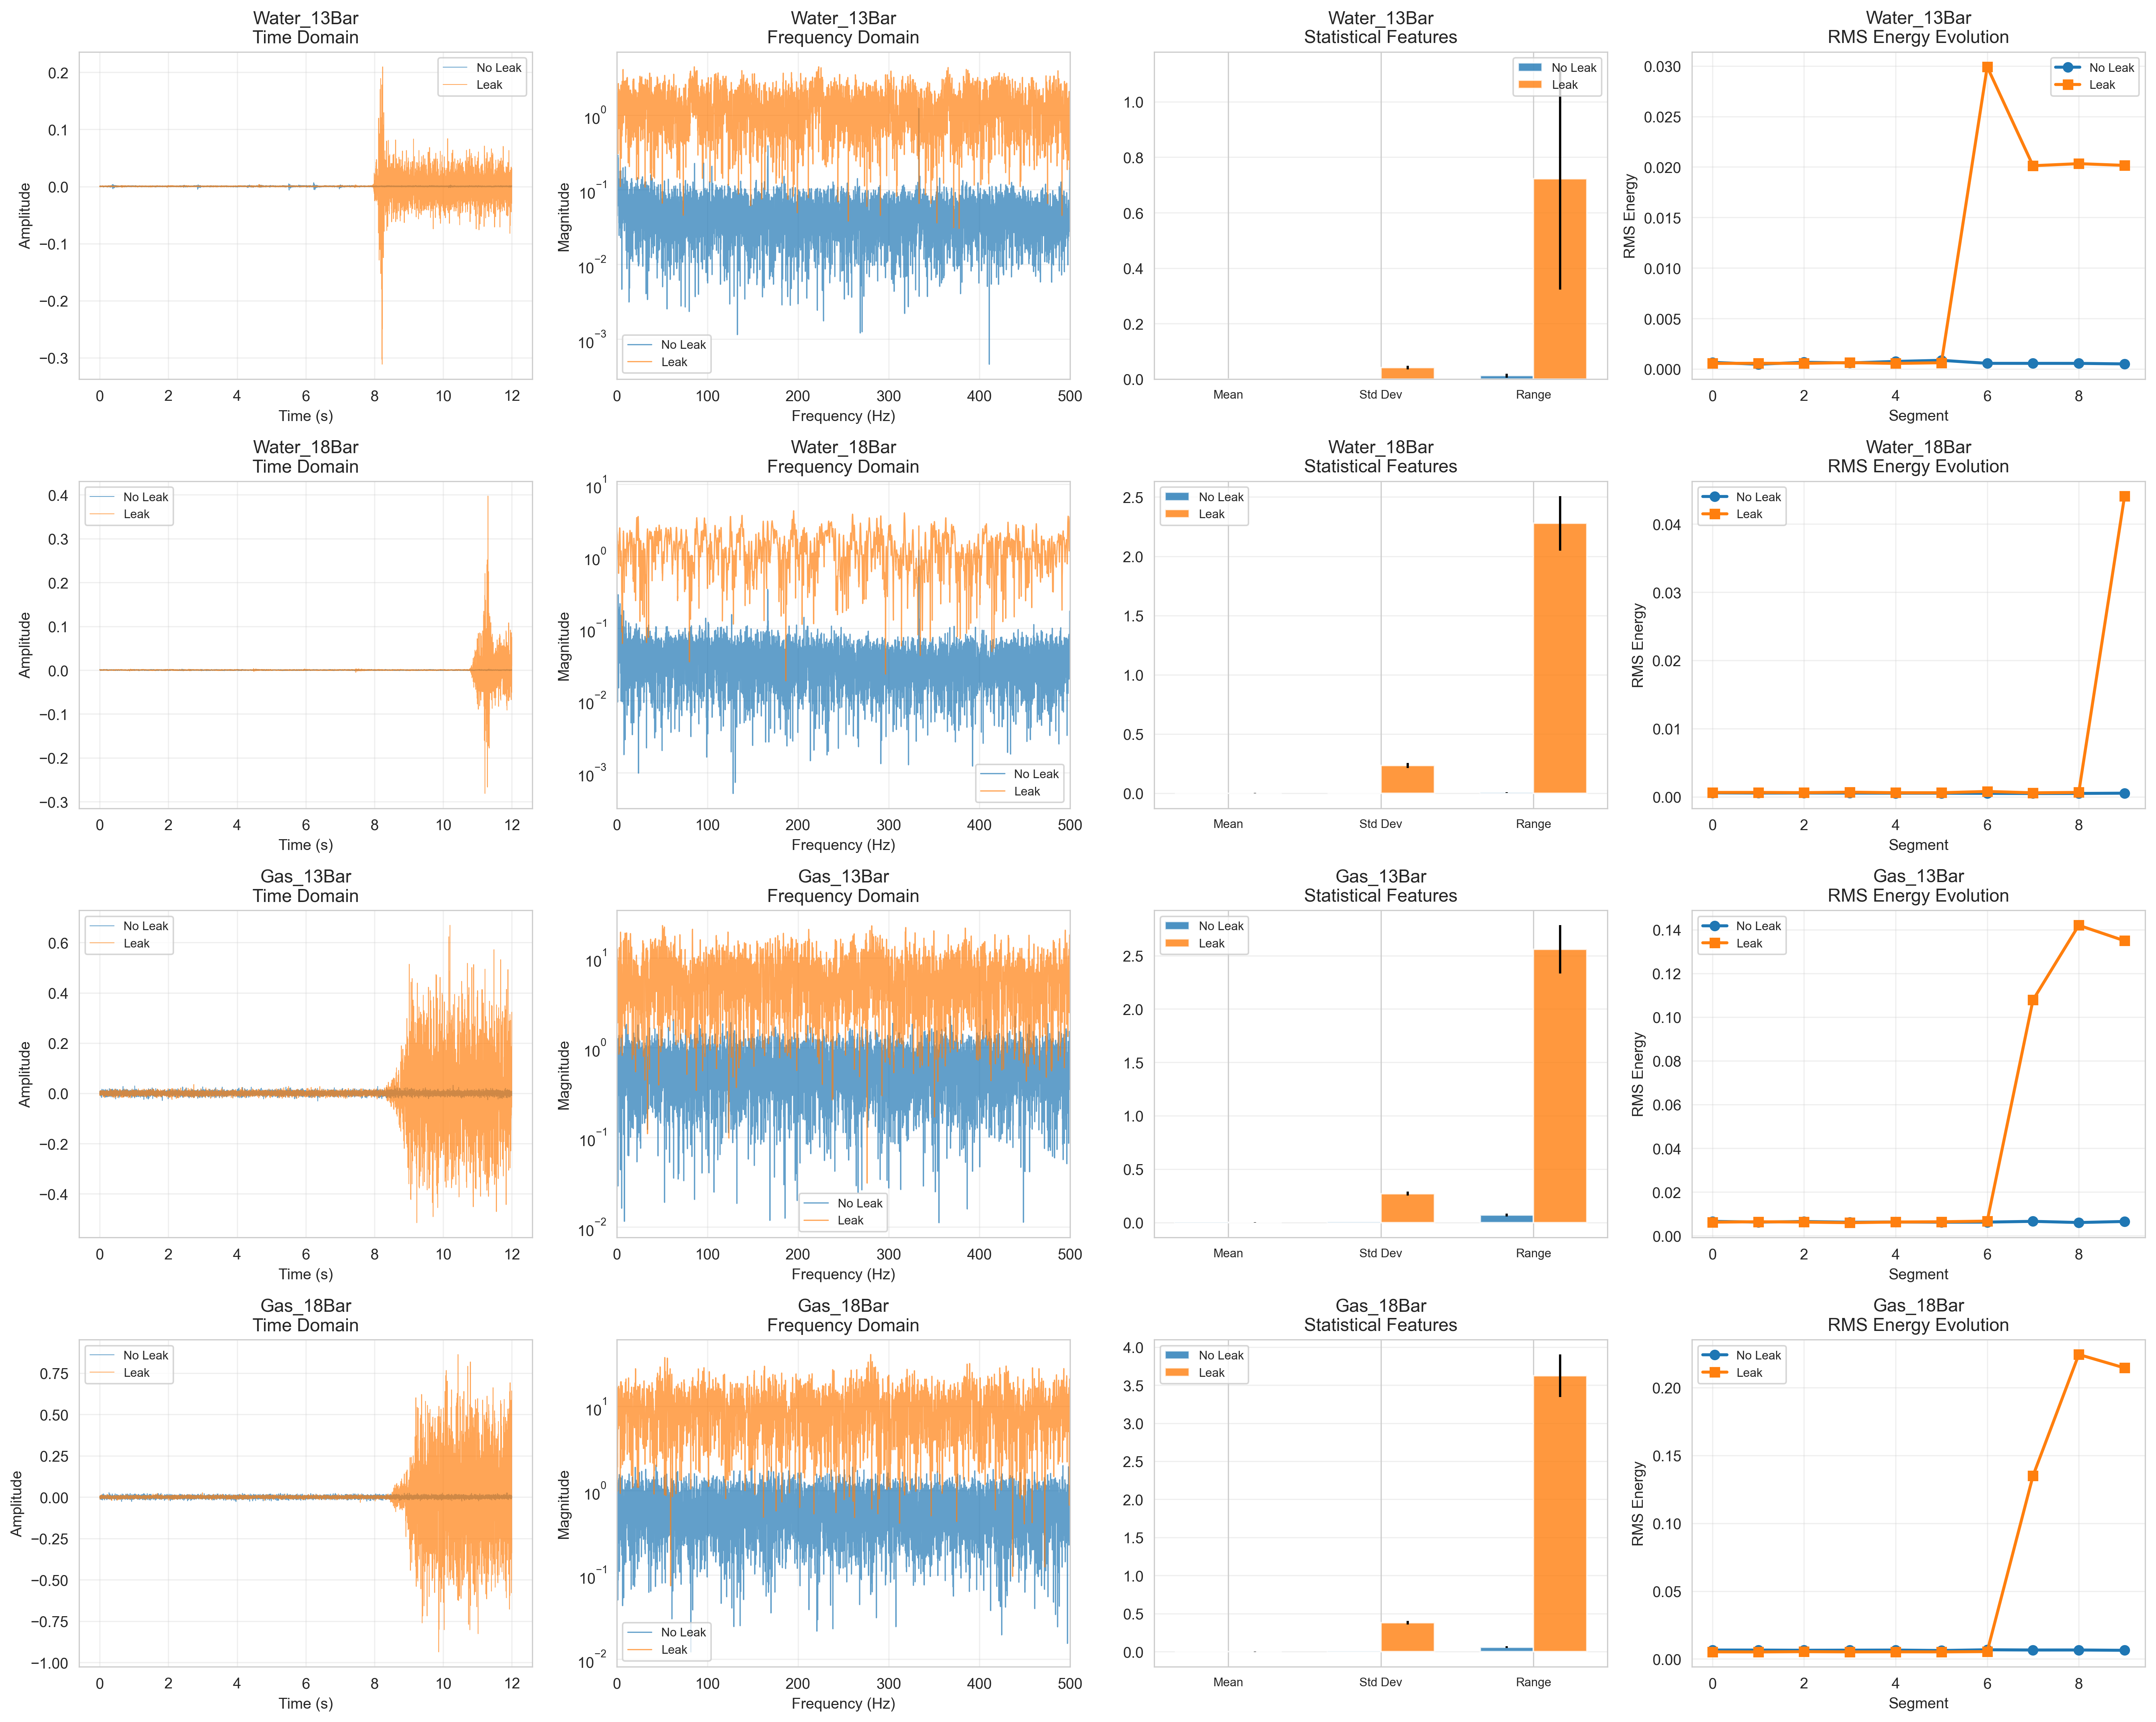

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
import pywt

# Set publication-quality plotting
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Function for comprehensive signal analysis
def analyze_signal_characteristics(datasets):
    """
    Create publication-quality signal analysis plots
    """
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    
    conditions = ['Water_13Bar', 'Water_18Bar', 'Gas_13Bar', 'Gas_18Bar']
    
    for idx, condition in enumerate(conditions):
        df = datasets[condition]
        signal_data = df.iloc[:, :-1].values  # Exclude label
        labels = df['label'].values
        
        # Get representative signals
        no_leak_signal = signal_data[labels == 0][0]
        leak_signal = signal_data[labels == 1][0]
        
        # 1. Time domain comparison
        ax = axes[idx, 0]
        time = np.arange(len(no_leak_signal)) / 1000  # Assuming 1kHz sampling
        ax.plot(time, no_leak_signal, label='No Leak', alpha=0.7, linewidth=0.5)
        ax.plot(time, leak_signal, label='Leak', alpha=0.7, linewidth=0.5)
        ax.set_title(f'{condition}\nTime Domain')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # 2. FFT - Frequency domain
        ax = axes[idx, 1]
        freqs = fftfreq(len(no_leak_signal), 1/1000)[:len(no_leak_signal)//2]
        
        fft_no_leak = np.abs(fft(no_leak_signal))[:len(no_leak_signal)//2]
        fft_leak = np.abs(fft(leak_signal))[:len(leak_signal)//2]
        
        ax.semilogy(freqs, fft_no_leak, label='No Leak', alpha=0.7, linewidth=0.8)
        ax.semilogy(freqs, fft_leak, label='Leak', alpha=0.7, linewidth=0.8)
        ax.set_title(f'{condition}\nFrequency Domain')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Magnitude')
        ax.set_xlim([0, 500])  # Focus on relevant range
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # 3. Statistical features distribution
        ax = axes[idx, 2]
        features_no_leak = np.array([
            np.mean(signal_data[labels == 0], axis=1),
            np.std(signal_data[labels == 0], axis=1),
            np.max(signal_data[labels == 0], axis=1) - np.min(signal_data[labels == 0], axis=1)
        ])
        features_leak = np.array([
            np.mean(signal_data[labels == 1], axis=1),
            np.std(signal_data[labels == 1], axis=1),
            np.max(signal_data[labels == 1], axis=1) - np.min(signal_data[labels == 1], axis=1)
        ])
        
        x_pos = np.arange(3)
        width = 0.35
        ax.bar(x_pos - width/2, [f.mean() for f in features_no_leak], width, 
               label='No Leak', alpha=0.8, yerr=[f.std() for f in features_no_leak])
        ax.bar(x_pos + width/2, [f.mean() for f in features_leak], width,
               label='Leak', alpha=0.8, yerr=[f.std() for f in features_leak])
        ax.set_title(f'{condition}\nStatistical Features')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(['Mean', 'Std Dev', 'Range'], fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
        
        # 4. RMS Energy over segments
        ax = axes[idx, 3]
        segment_length = len(no_leak_signal) // 10
        segments = np.arange(10)
        
        rms_no_leak = [np.sqrt(np.mean(no_leak_signal[i*segment_length:(i+1)*segment_length]**2)) 
                       for i in range(10)]
        rms_leak = [np.sqrt(np.mean(leak_signal[i*segment_length:(i+1)*segment_length]**2)) 
                    for i in range(10)]
        
        ax.plot(segments, rms_no_leak, 'o-', label='No Leak', linewidth=2, markersize=6)
        ax.plot(segments, rms_leak, 's-', label='Leak', linewidth=2, markersize=6)
        ax.set_title(f'{condition}\nRMS Energy Evolution')
        ax.set_xlabel('Segment')
        ax.set_ylabel('RMS Energy')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('signal_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: signal_analysis_comprehensive.png")
    plt.show()

# Run the analysis
analyze_signal_characteristics(datasets)

Extracting wavelet features...
Processing Water_13Bar...
Processing Water_18Bar...
Processing Gas_13Bar...
Processing Gas_18Bar...

✅ Feature extraction complete!
Feature matrix shape: (1440, 41)
Total samples: 1440
Feature dimension: 41

Creating PCA visualization...
✅ Saved: feature_space_pca.png


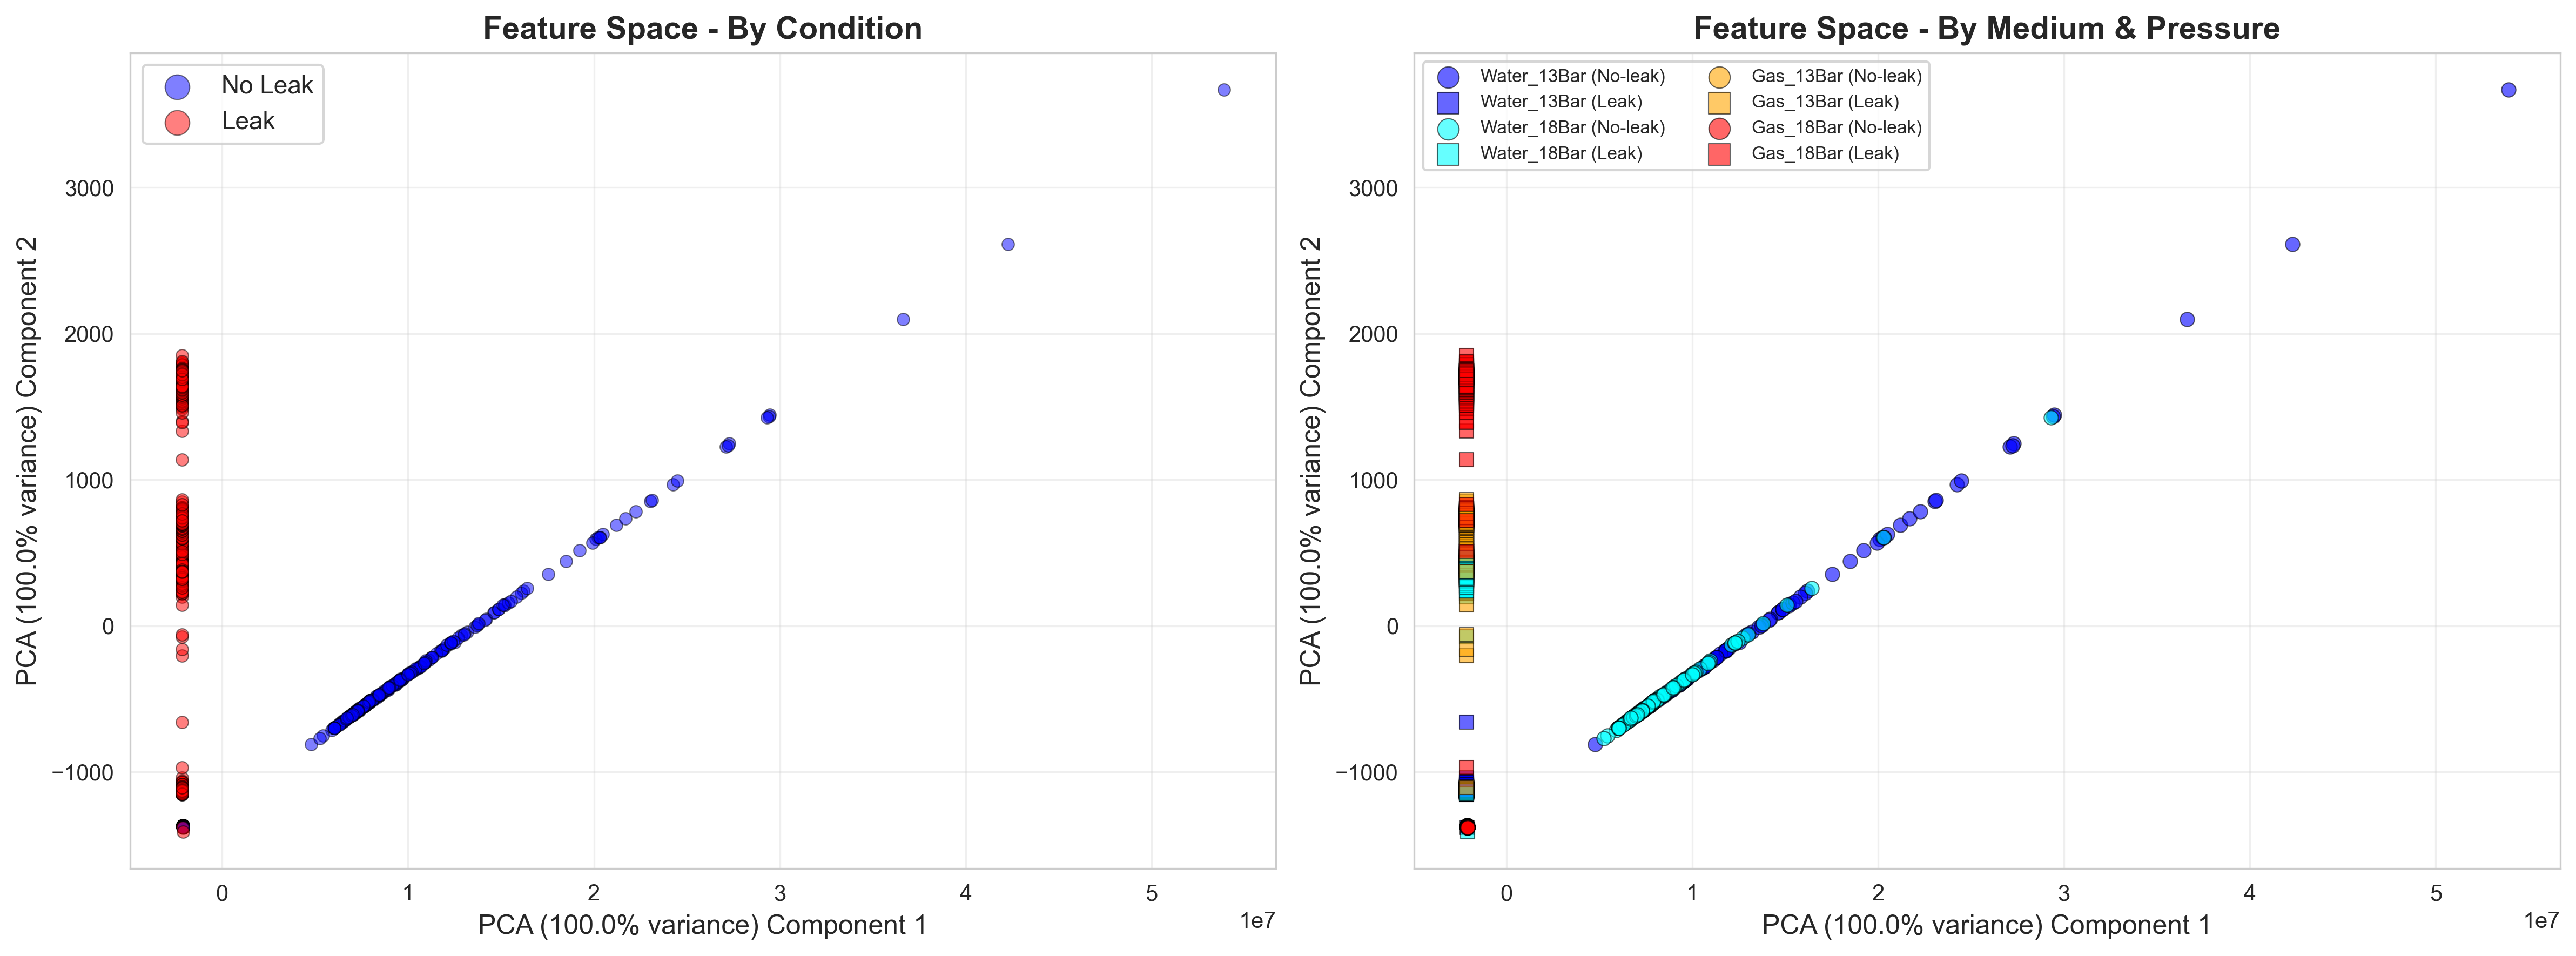


Creating t-SNE visualization...
✅ Saved: feature_space_tsne.png


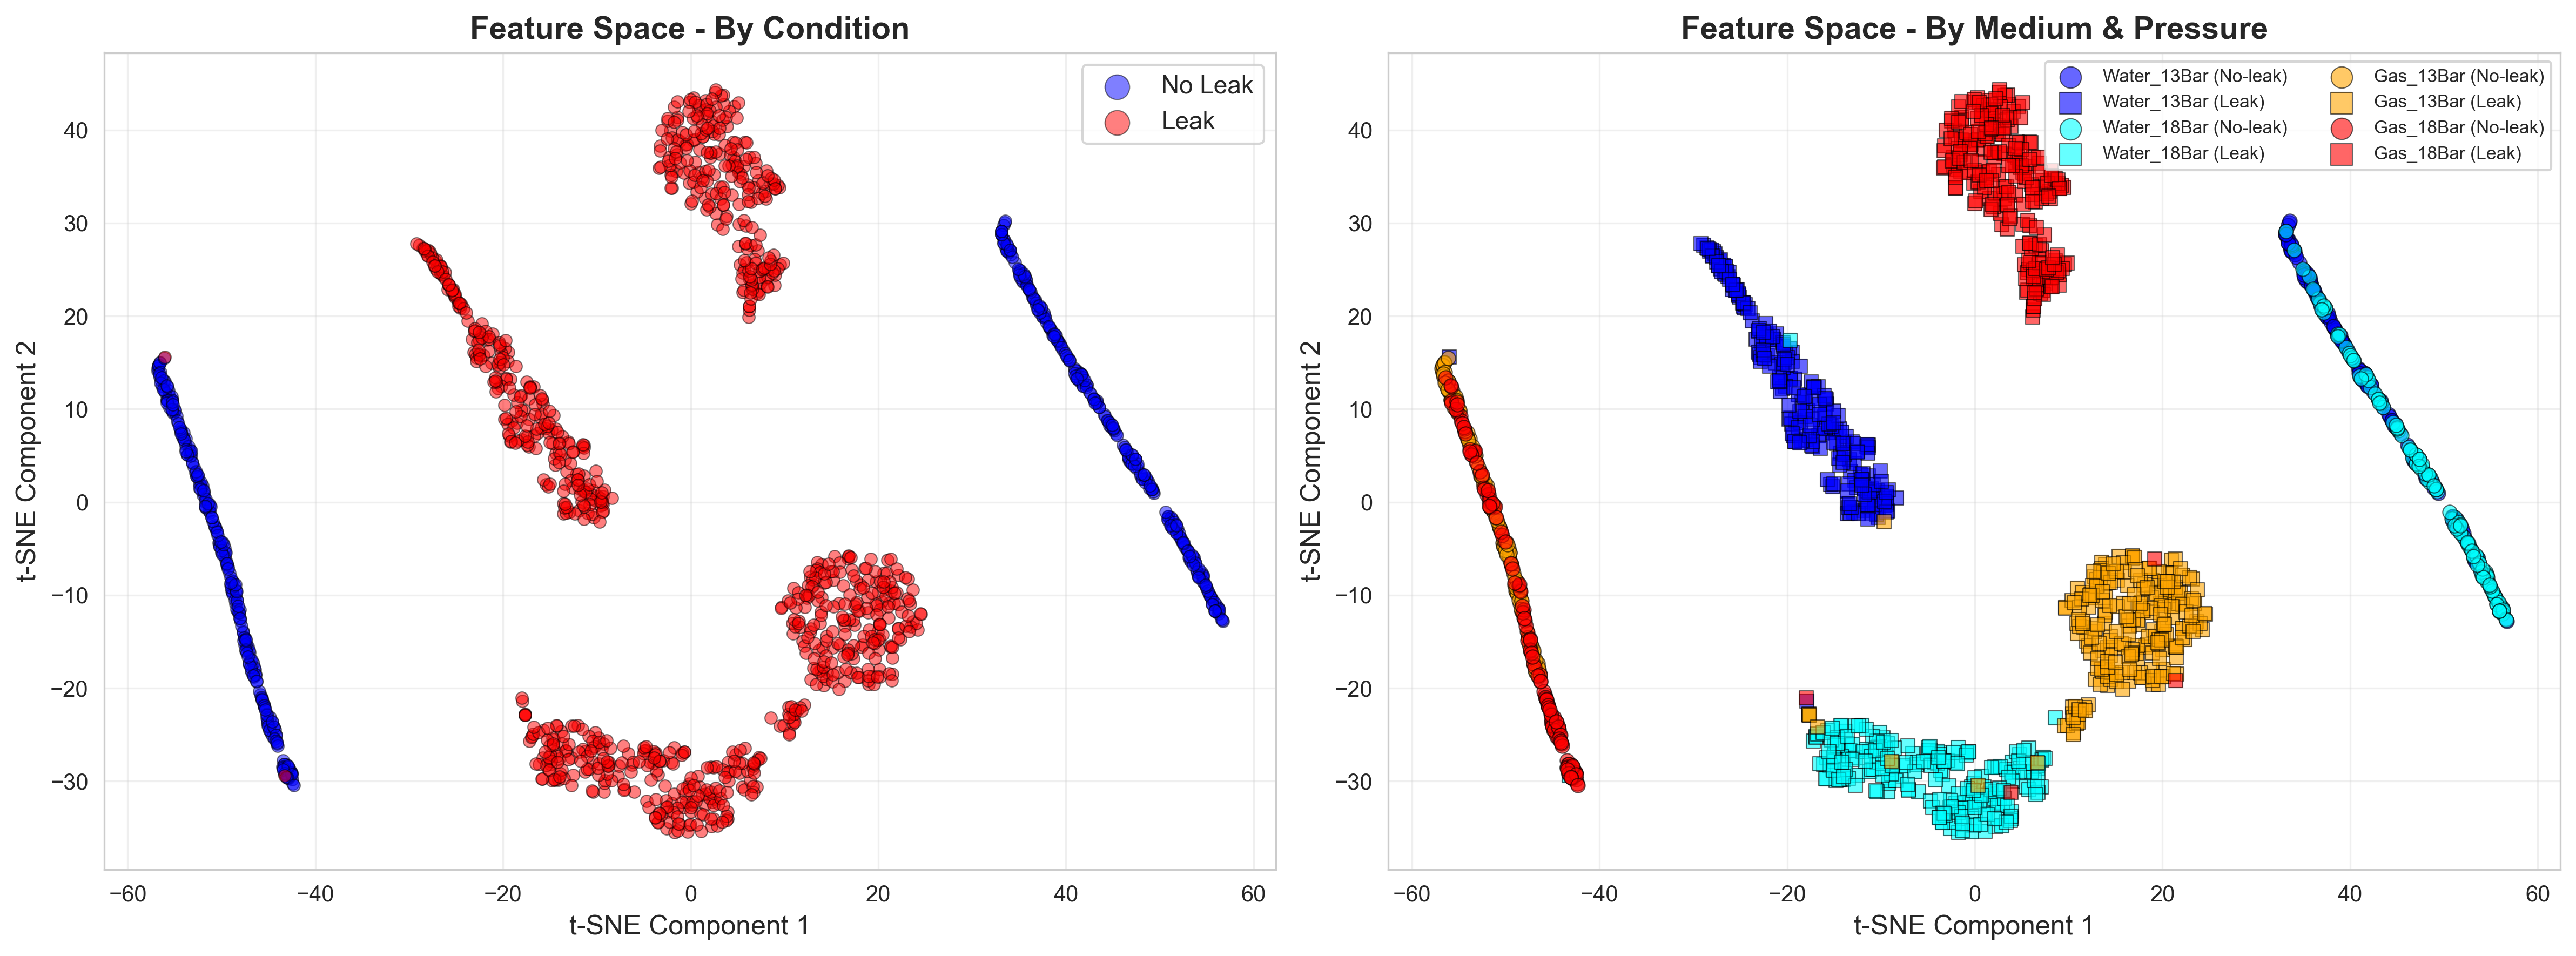

In [4]:
import pywt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

def extract_wavelet_features(signal, wavelet='db4', level=5):
    """
    Extract multi-scale wavelet features from AE signal
    Features that MSSP reviewers will appreciate!
    """
    # Decompose signal
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    
    features = []
    
    # For each decomposition level
    for i, coeff in enumerate(coeffs):
        # Energy
        energy = np.sum(coeff**2)
        features.append(energy)
        
        # Statistical moments
        features.append(np.mean(np.abs(coeff)))  # Mean absolute value
        features.append(np.std(coeff))            # Standard deviation
        features.append(np.max(np.abs(coeff)))    # Peak amplitude
        
        # Shape features
        if len(coeff) > 0:
            features.append(np.sum(np.abs(np.diff(coeff))))  # Total variation
            features.append(len(np.where(np.diff(np.sign(coeff)))[0]))  # Zero crossings
    
    # Time-domain features from original signal
    features.extend([
        np.sqrt(np.mean(signal**2)),  # RMS
        np.mean(np.abs(signal)),       # Mean absolute
        np.max(signal) - np.min(signal),  # Peak-to-peak
        len(np.where(np.diff(np.sign(signal)))[0]) / len(signal),  # Zero crossing rate
        np.sqrt(np.mean((signal - np.mean(signal))**4)) / (np.std(signal)**4)  # Kurtosis
    ])
    
    return np.array(features)

def create_feature_dataset(datasets, feature_type='wavelet'):
    """
    Create comprehensive feature dataset for all conditions
    """
    all_features = []
    all_labels = []
    all_conditions = []
    
    for condition_name, df in datasets.items():
        print(f"Processing {condition_name}...")
        
        signals = df.iloc[:, :-1].values
        labels = df['label'].values
        
        for idx, signal in enumerate(signals):
            if feature_type == 'wavelet':
                feat = extract_wavelet_features(signal)
            
            all_features.append(feat)
            all_labels.append(labels[idx])
            all_conditions.append(condition_name)
    
    return np.array(all_features), np.array(all_labels), np.array(all_conditions)

# Extract features from all datasets
print("Extracting wavelet features...")
X_wavelet, y, conditions = create_feature_dataset(datasets, 'wavelet')

print(f"\n✅ Feature extraction complete!")
print(f"Feature matrix shape: {X_wavelet.shape}")
print(f"Total samples: {len(y)}")
print(f"Feature dimension: {X_wavelet.shape[1]}")

# Visualize feature separability
def visualize_feature_space(X, y, conditions, method='tsne'):
    """
    Create publication-quality feature space visualization
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Apply dimensionality reduction
    if method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        X_2d = reducer.fit_transform(X)
        title_suffix = "t-SNE"
    else:
        reducer = PCA(n_components=2, random_state=42)
        X_2d = reducer.fit_transform(X)
        title_suffix = f"PCA ({reducer.explained_variance_ratio_[:2].sum()*100:.1f}% variance)"
    
    # Plot 1: By leak/no-leak
    ax = axes[0]
    scatter1 = ax.scatter(X_2d[y==0, 0], X_2d[y==0, 1], 
                          c='blue', alpha=0.5, s=30, label='No Leak', edgecolors='k', linewidth=0.5)
    scatter2 = ax.scatter(X_2d[y==1, 0], X_2d[y==1, 1], 
                          c='red', alpha=0.5, s=30, label='Leak', edgecolors='k', linewidth=0.5)
    ax.set_xlabel(f'{title_suffix} Component 1', fontsize=12)
    ax.set_ylabel(f'{title_suffix} Component 2', fontsize=12)
    ax.set_title('Feature Space - By Condition', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, markerscale=2)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: By medium and pressure
    ax = axes[1]
    colors = {'Water_13Bar': 'blue', 'Water_18Bar': 'cyan', 
              'Gas_13Bar': 'orange', 'Gas_18Bar': 'red'}
    markers = {0: 'o', 1: 's'}  # circle for no-leak, square for leak
    
    for condition in ['Water_13Bar', 'Water_18Bar', 'Gas_13Bar', 'Gas_18Bar']:
        mask = conditions == condition
        for label in [0, 1]:
            label_mask = y == label
            combined_mask = mask & label_mask
            label_str = "Leak" if label == 1 else "No-leak"
            ax.scatter(X_2d[combined_mask, 0], X_2d[combined_mask, 1],
                      c=colors[condition], marker=markers[label],
                      alpha=0.6, s=40, 
                      label=f'{condition} ({label_str})',
                      edgecolors='k', linewidth=0.5)
    
    ax.set_xlabel(f'{title_suffix} Component 1', fontsize=12)
    ax.set_ylabel(f'{title_suffix} Component 2', fontsize=12)
    ax.set_title('Feature Space - By Medium & Pressure', fontsize=14, fontweight='bold')
    ax.legend(fontsize=8, ncol=2, loc='best', markerscale=1.5)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'feature_space_{method}.png', dpi=300, bbox_inches='tight')
    print(f"✅ Saved: feature_space_{method}.png")
    plt.show()

# Visualize with both PCA and t-SNE
print("\nCreating PCA visualization...")
visualize_feature_space(X_wavelet, y, conditions, method='pca')

print("\nCreating t-SNE visualization...")
visualize_feature_space(X_wavelet, y, conditions, method='tsne')

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd

def cross_condition_evaluation(X, y, conditions):
    """
    THE COMPREHENSIVE MSSP EVALUATION FRAMEWORK
    16 different train/test scenarios!
    """
    
    results = []
    
    # Define all experimental scenarios
    scenarios = [
        # Within-condition (baseline)
        ('Water_13Bar', 'Water_13Bar', 'Within-Medium-Pressure'),
        ('Water_18Bar', 'Water_18Bar', 'Within-Medium-Pressure'),
        ('Gas_13Bar', 'Gas_13Bar', 'Within-Medium-Pressure'),
        ('Gas_18Bar', 'Gas_18Bar', 'Within-Medium-Pressure'),
        
        # Cross-pressure (same medium)
        ('Water_13Bar', 'Water_18Bar', 'Cross-Pressure'),
        ('Water_18Bar', 'Water_13Bar', 'Cross-Pressure'),
        ('Gas_13Bar', 'Gas_18Bar', 'Cross-Pressure'),
        ('Gas_18Bar', 'Gas_13Bar', 'Cross-Pressure'),
        
        # Cross-medium (same pressure) - THE HARD TEST
        ('Water_13Bar', 'Gas_13Bar', 'Cross-Medium'),
        ('Gas_13Bar', 'Water_13Bar', 'Cross-Medium'),
        ('Water_18Bar', 'Gas_18Bar', 'Cross-Medium'),
        ('Gas_18Bar', 'Water_18Bar', 'Cross-Medium'),
        
        # Mixed training (combined conditions)
        ('Water_13Bar+Water_18Bar', 'Gas_13Bar', 'Mixed-to-Cross'),
        ('Gas_13Bar+Gas_18Bar', 'Water_13Bar', 'Mixed-to-Cross'),
        ('Water_13Bar+Gas_13Bar', 'Water_18Bar', 'Mixed-to-Cross'),
        ('Water_18Bar+Gas_18Bar', 'Gas_13Bar', 'Mixed-to-Cross'),
    ]
    
    # Models to evaluate - FIXED HERE
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
        'SVM-RBF': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
        'MLP': MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)
    }
    
    print("=" * 80)
    print("COMPREHENSIVE CROSS-CONDITION EVALUATION")
    print("=" * 80)
    
    for train_cond, test_cond, scenario_type in scenarios:
        print(f"\n{'='*60}")
        print(f"Scenario: Train on {train_cond} → Test on {test_cond}")
        print(f"Type: {scenario_type}")
        print(f"{'='*60}")
        
        # Prepare training data
        if '+' in train_cond:
            conds = train_cond.split('+')
            train_mask = np.isin(conditions, conds)
        else:
            train_mask = conditions == train_cond
        
        # Prepare test data
        test_mask = conditions == test_cond
        
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test = X[test_mask]
        y_test = y[test_mask]
        
        # Standardize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        print(f"Train samples: {len(y_train)} | Test samples: {len(y_test)}")
        
        # Evaluate each model
        for model_name, model in models.items():
            # Train
            model.fit(X_train_scaled, y_train)
            
            # Predict
            y_pred = model.predict(X_test_scaled)
            
            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            # Confusion matrix
            cm = confusion_matrix(y_test, y_pred)
            
            # Store results
            results.append({
                'Train_Condition': train_cond,
                'Test_Condition': test_cond,
                'Scenario_Type': scenario_type,
                'Model': model_name,
                'Accuracy': acc * 100,
                'Precision': prec * 100,
                'Recall': rec * 100,
                'F1_Score': f1 * 100,
                'TN': cm[0,0] if cm.shape[0] > 1 else 0,
                'FP': cm[0,1] if cm.shape[0] > 1 else 0,
                'FN': cm[1,0] if cm.shape[0] > 1 else 0,
                'TP': cm[1,1] if cm.shape[0] > 1 else 0
            })
            
            print(f"  {model_name:15s} → Acc: {acc*100:6.2f}% | Prec: {prec*100:6.2f}% | Rec: {rec*100:6.2f}% | F1: {f1*100:6.2f}%")
    
    return pd.DataFrame(results)

# Run comprehensive evaluation
print("\n🚀 Starting comprehensive cross-condition evaluation...")
results_df = cross_condition_evaluation(X_wavelet, y, conditions)

# Save results
results_df.to_csv('cross_condition_results.csv', index=False)
print("\n✅ Results saved to: cross_condition_results.csv")

# Display summary statistics by scenario type
print("\n" + "="*80)
print("SUMMARY BY SCENARIO TYPE")
print("="*80)
summary = results_df.groupby(['Scenario_Type', 'Model'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean', 'std'])
print(summary)


🚀 Starting comprehensive cross-condition evaluation...
COMPREHENSIVE CROSS-CONDITION EVALUATION

Scenario: Train on Water_13Bar → Test on Water_13Bar
Type: Within-Medium-Pressure
Train samples: 360 | Test samples: 360
  Random Forest   → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%
  SVM-RBF         → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%
  MLP             → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%

Scenario: Train on Water_18Bar → Test on Water_18Bar
Type: Within-Medium-Pressure
Train samples: 360 | Test samples: 360
  Random Forest   → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%
  SVM-RBF         → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%
  MLP             → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100.00%

Scenario: Train on Gas_13Bar → Test on Gas_13Bar
Type: Within-Medium-Pressure
Train samples: 360 | Test samples: 360
  Random Forest   → Acc: 100.00% | Prec: 100.00% | Rec: 100.00% | F1: 100


🎨 Creating publication-quality visualizations...
✅ Saved: transfer_learning_heatmap.png


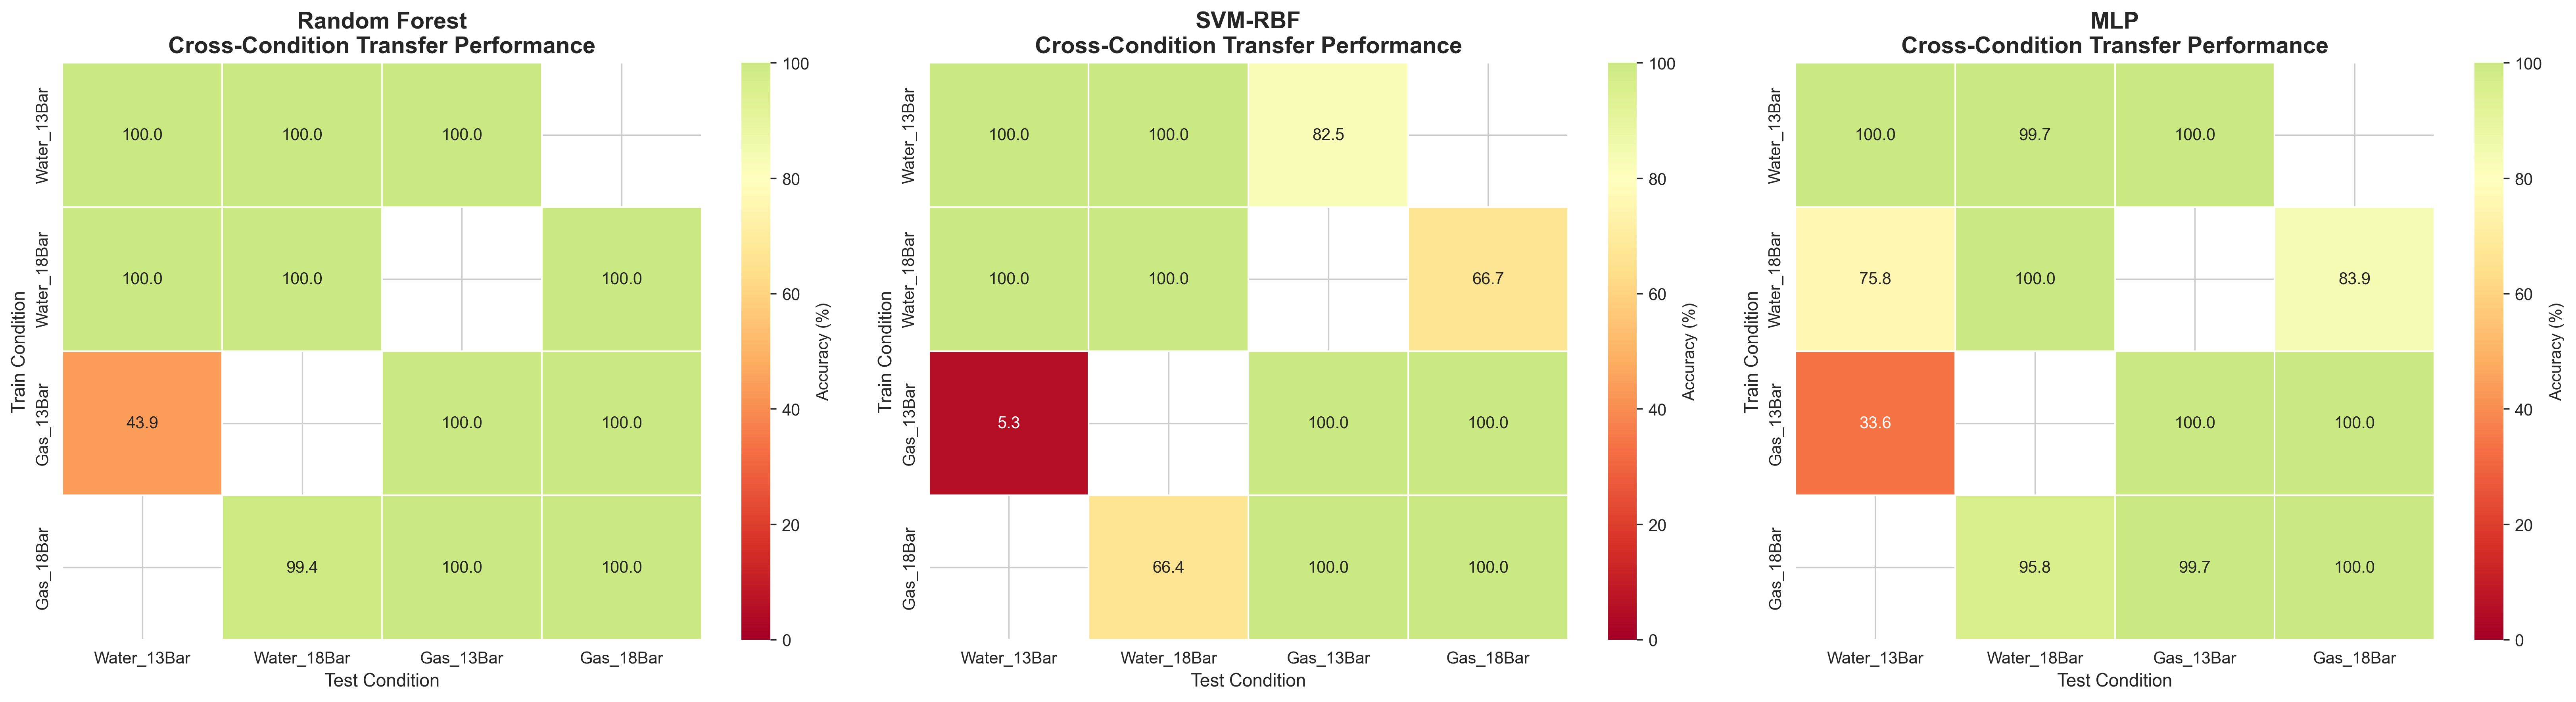

✅ Saved: scenario_comparison_bars.png


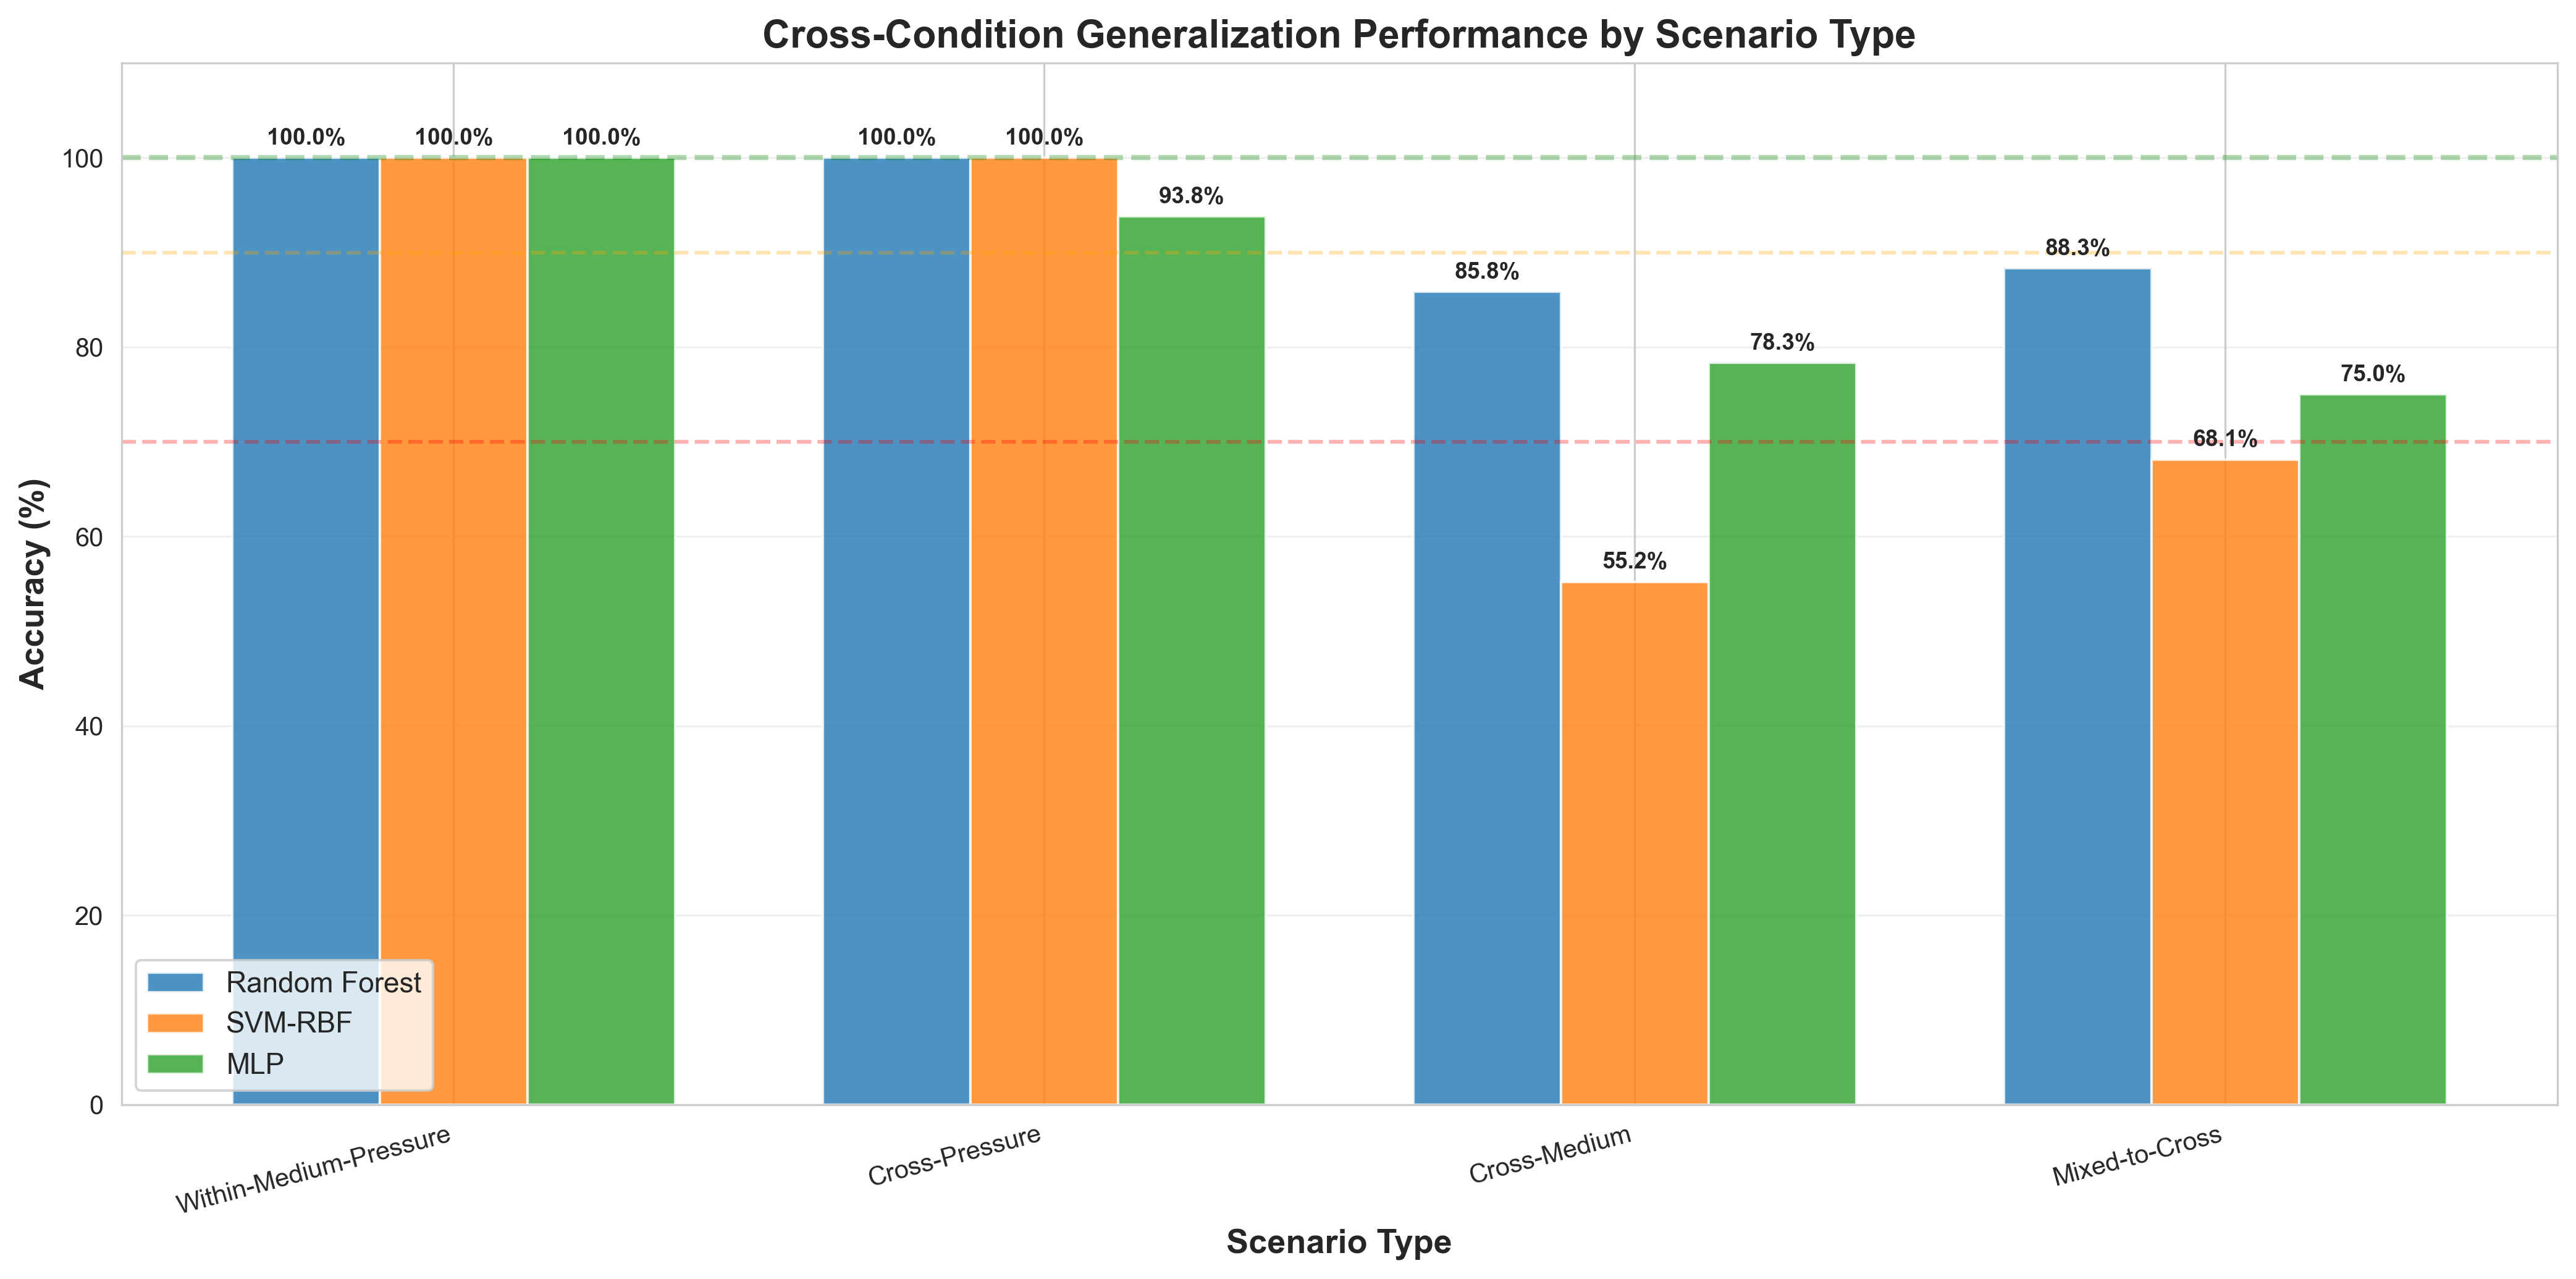

✅ Saved: cross_medium_detailed_metrics.png


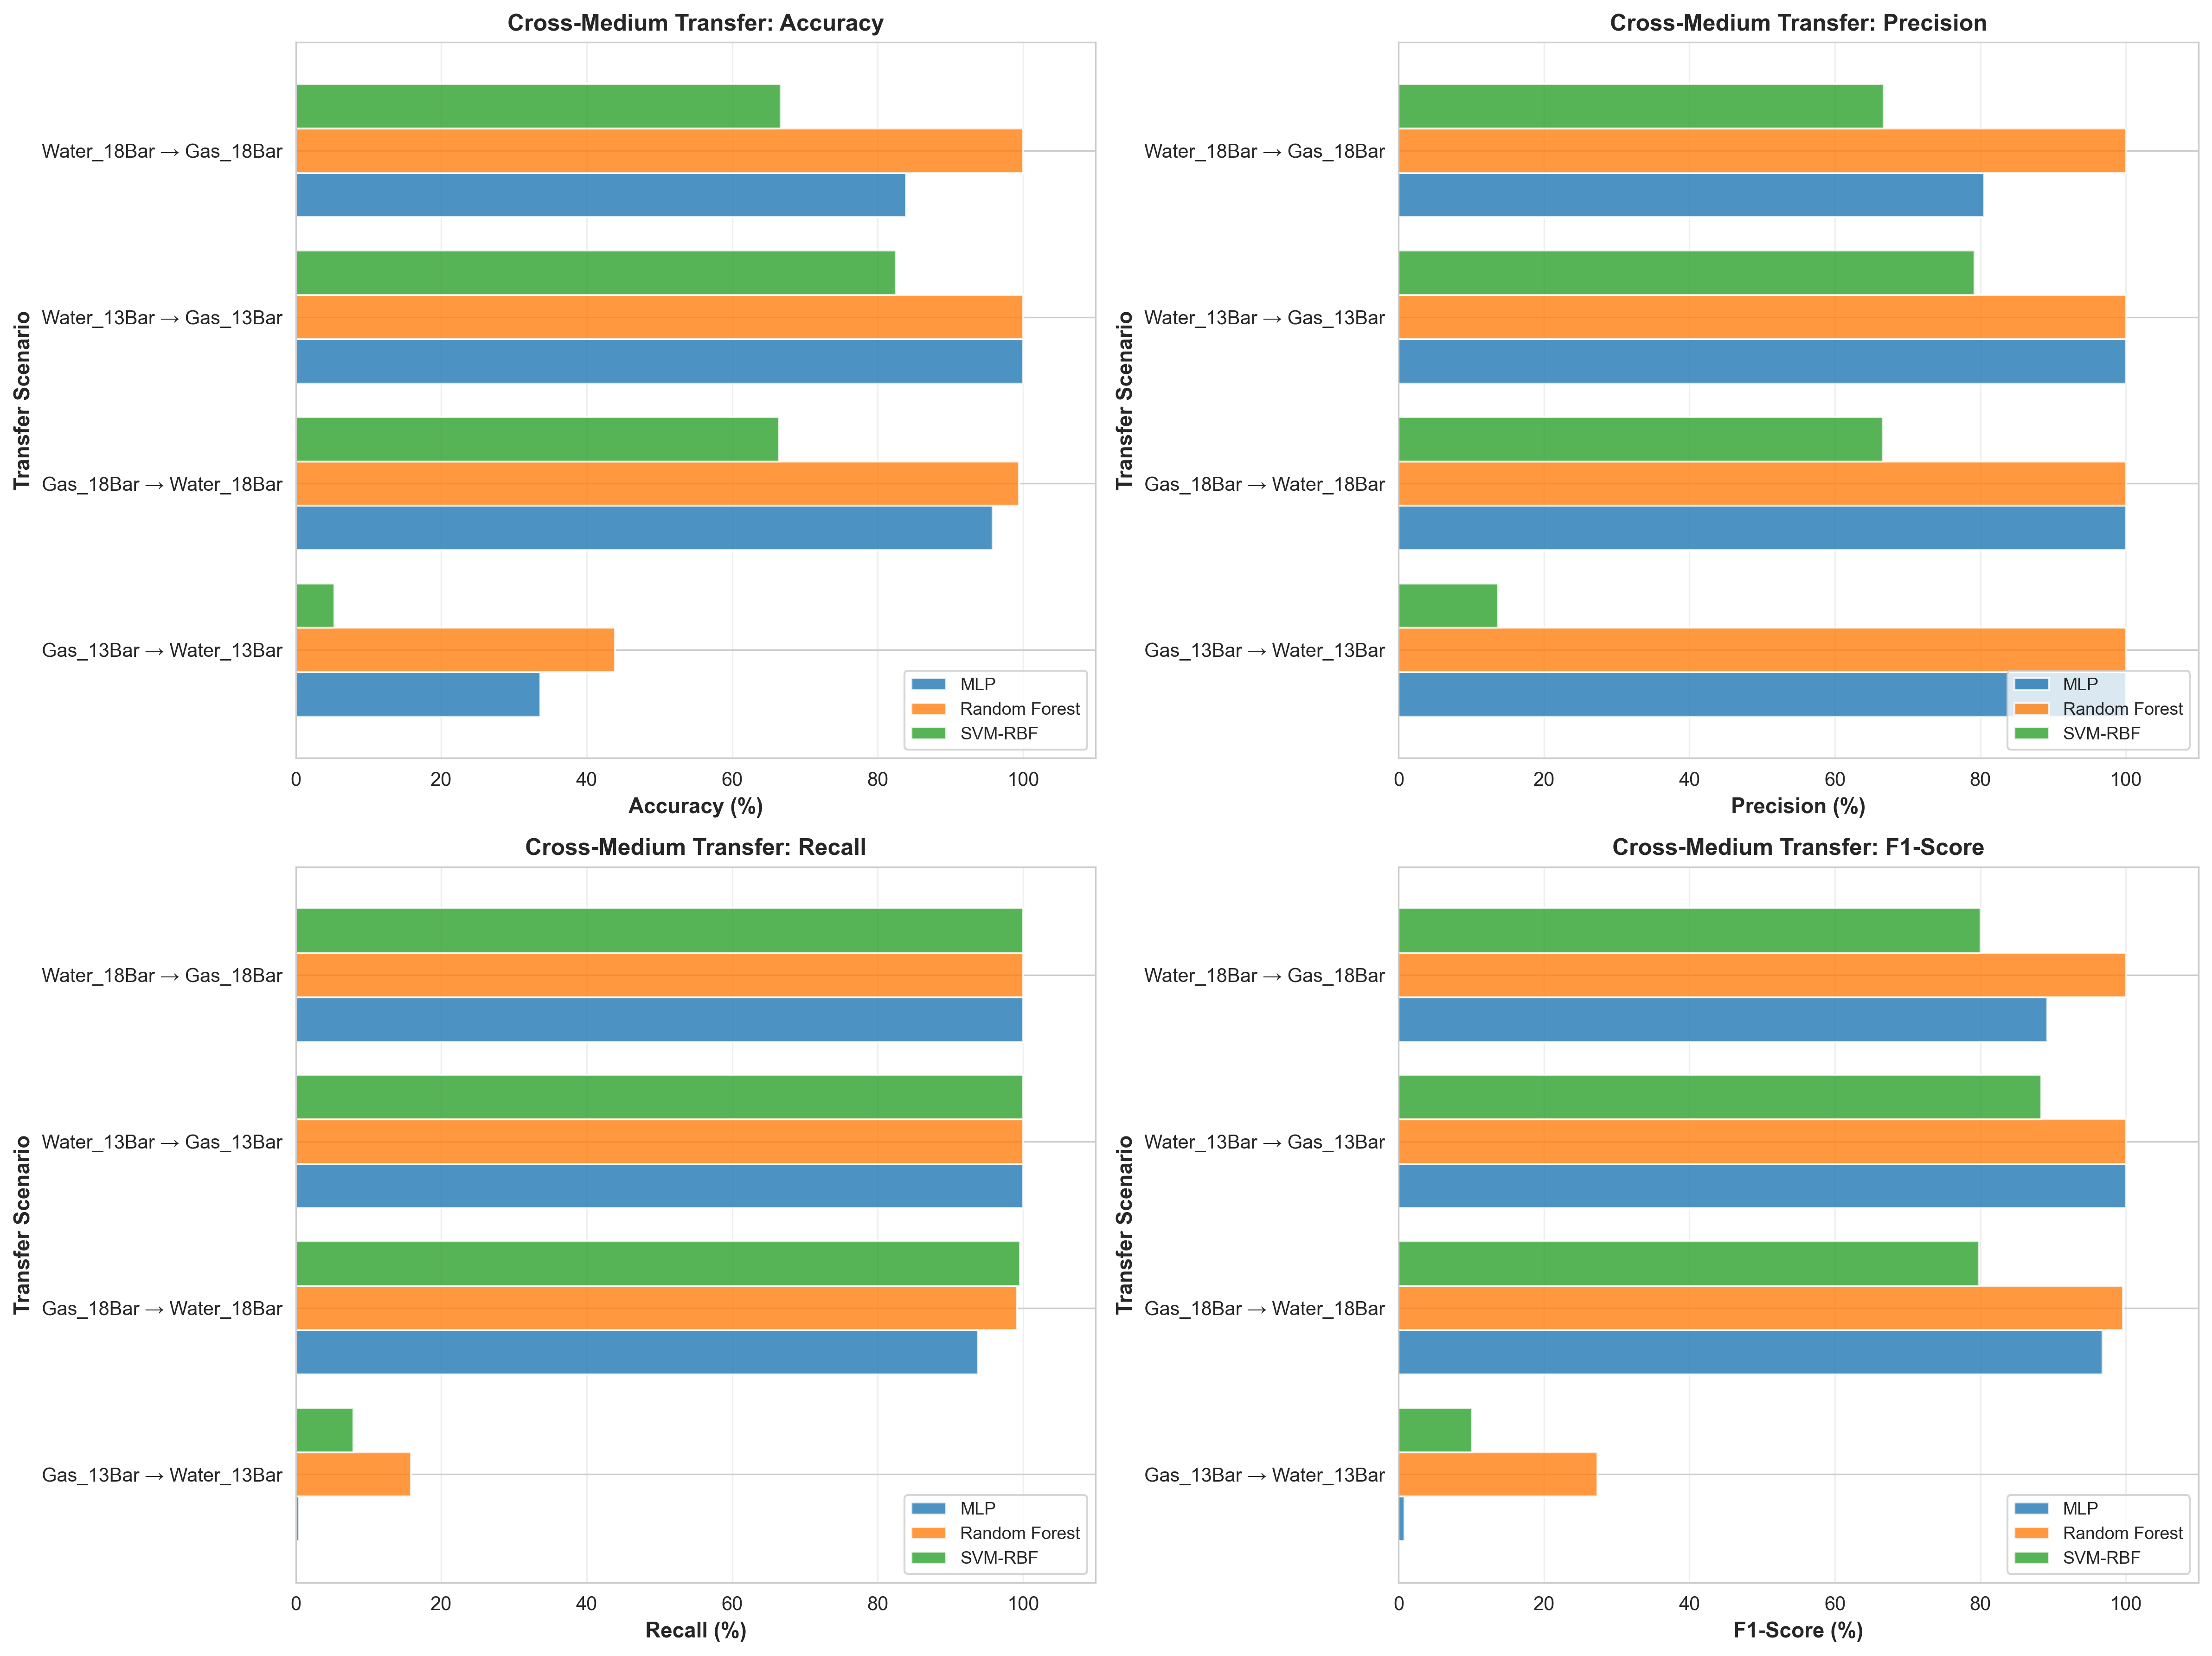


TABLE FOR MSSP PAPER - CROSS-CONDITION TRANSFER RESULTS

Best model per scenario type:
                                Model  Accuracy          Train_Condition  \
Scenario_Type                                                              
Cross-Medium            Random Forest     100.0              Water_13Bar   
Cross-Pressure          Random Forest     100.0              Water_13Bar   
Mixed-to-Cross          Random Forest     100.0  Water_13Bar+Water_18Bar   
Within-Medium-Pressure  Random Forest     100.0              Water_13Bar   

                       Test_Condition  
Scenario_Type                          
Cross-Medium                Gas_13Bar  
Cross-Pressure            Water_18Bar  
Mixed-to-Cross              Gas_13Bar  
Within-Medium-Pressure    Water_13Bar  


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create comprehensive results visualization
def create_publication_plots(results_df):
    """
    Create MSSP-quality result visualizations
    """
    
    # Figure 1: Heatmap of all scenarios
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    models = ['Random Forest', 'SVM-RBF', 'MLP']
    
    for idx, model in enumerate(models):
        ax = axes[idx]
        
        # Filter data for this model
        model_data = results_df[results_df['Model'] == model].copy()
        
        # Create pivot table
        pivot = model_data.pivot_table(
            values='Accuracy', 
            index='Train_Condition', 
            columns='Test_Condition'
        )
        
        # Reorder for better visualization
        order = ['Water_13Bar', 'Water_18Bar', 'Gas_13Bar', 'Gas_18Bar']
        pivot = pivot.reindex(index=order, columns=order)
        
        # Create heatmap
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', 
                    vmin=0, vmax=100, center=80,
                    cbar_kws={'label': 'Accuracy (%)'},
                    ax=ax, linewidths=0.5)
        
        ax.set_title(f'{model}\nCross-Condition Transfer Performance', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Test Condition', fontsize=11)
        ax.set_ylabel('Train Condition', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('transfer_learning_heatmap.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: transfer_learning_heatmap.png")
    plt.show()
    
    # Figure 2: Bar chart comparison by scenario type
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Prepare data
    summary = results_df.groupby(['Scenario_Type', 'Model'])['Accuracy'].mean().reset_index()
    
    # Define order
    scenario_order = ['Within-Medium-Pressure', 'Cross-Pressure', 'Cross-Medium', 'Mixed-to-Cross']
    summary['Scenario_Type'] = pd.Categorical(summary['Scenario_Type'], 
                                               categories=scenario_order, 
                                               ordered=True)
    summary = summary.sort_values('Scenario_Type')
    
    # Create grouped bar chart
    x = np.arange(len(scenario_order))
    width = 0.25
    
    for idx, model in enumerate(['Random Forest', 'SVM-RBF', 'MLP']):
        model_data = summary[summary['Model'] == model]
        values = [model_data[model_data['Scenario_Type'] == s]['Accuracy'].values[0] 
                  for s in scenario_order]
        
        ax.bar(x + idx*width, values, width, label=model, alpha=0.8)
        
        # Add value labels on bars
        for i, v in enumerate(values):
            ax.text(x[i] + idx*width, v + 1, f'{v:.1f}%', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Scenario Type', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    ax.set_title('Cross-Condition Generalization Performance by Scenario Type', 
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(scenario_order, rotation=15, ha='right')
    ax.legend(fontsize=11, loc='lower left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 110])
    
    # Add horizontal reference lines
    ax.axhline(y=100, color='green', linestyle='--', alpha=0.3, linewidth=2, label='Perfect')
    ax.axhline(y=90, color='orange', linestyle='--', alpha=0.3, linewidth=1.5, label='Excellent')
    ax.axhline(y=70, color='red', linestyle='--', alpha=0.3, linewidth=1.5, label='Good')
    
    plt.tight_layout()
    plt.savefig('scenario_comparison_bars.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: scenario_comparison_bars.png")
    plt.show()
    
    # Figure 3: Detailed metrics comparison for cross-medium transfer
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    cross_medium_data = results_df[results_df['Scenario_Type'] == 'Cross-Medium'].copy()
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
    titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]
        
        # Create grouped data
        scenarios = cross_medium_data['Train_Condition'] + ' → ' + cross_medium_data['Test_Condition']
        cross_medium_data['Scenario'] = scenarios
        
        pivot = cross_medium_data.pivot_table(values=metric, 
                                               index='Scenario', 
                                               columns='Model')
        
        pivot.plot(kind='barh', ax=ax, width=0.8, alpha=0.8)
        ax.set_xlabel(f'{title} (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Transfer Scenario', fontsize=11, fontweight='bold')
        ax.set_title(f'Cross-Medium Transfer: {title}', 
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(True, alpha=0.3, axis='x')
        ax.set_xlim([0, 110])
    
    plt.tight_layout()
    plt.savefig('cross_medium_detailed_metrics.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: cross_medium_detailed_metrics.png")
    plt.show()

# Create all publication plots
print("\n🎨 Creating publication-quality visualizations...")
create_publication_plots(results_df)

# Create MSSP-style results table
print("\n" + "="*100)
print("TABLE FOR MSSP PAPER - CROSS-CONDITION TRANSFER RESULTS")
print("="*100)

# Format for paper
table_data = results_df.pivot_table(
    values=['Accuracy', 'Precision', 'Recall', 'F1_Score'],
    index=['Scenario_Type', 'Train_Condition', 'Test_Condition'],
    columns='Model'
)

print("\nBest model per scenario type:")
best_models = results_df.groupby('Scenario_Type').apply(
    lambda x: x.loc[x['Accuracy'].idxmax(), ['Model', 'Accuracy', 'Train_Condition', 'Test_Condition']]
)
print(best_models)

In [8]:
# Let's analyze your data structure more carefully
print("Analyzing data structure for leak size information...")

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"Shape: {df.shape}")
    print(f"Labels distribution:")
    print(df['label'].value_counts())
    
    # Let's see if there's any pattern in the data
    # Check if leak samples have different characteristics
    leak_data = df[df['label'] == 1]
    
    if len(leak_data) > 0:
        # Analyze amplitude patterns
        signals = leak_data.iloc[:, :-1].values
        max_amplitudes = np.max(np.abs(signals), axis=1)
        
        print(f"Leak amplitude range: {max_amplitudes.min():.6f} to {max_amplitudes.max():.6f}")
        print(f"Leak amplitude mean: {max_amplitudes.mean():.6f}")
        print(f"Leak amplitude std: {max_amplitudes.std():.6f}")

Analyzing data structure for leak size information...

Water_13Bar:
Shape: (360, 12001)
Labels distribution:
label
1    240
0    120
Name: count, dtype: int64
Leak amplitude range: 0.174080 to 1.655900
Leak amplitude mean: 0.405432
Leak amplitude std: 0.237072

Water_18Bar:
Shape: (360, 12001)
Labels distribution:
label
1    240
0    120
Name: count, dtype: int64
Leak amplitude range: 0.257500 to 1.524100
Leak amplitude mean: 1.193738
Leak amplitude std: 0.130995

Gas_13Bar:
Shape: (360, 12001)
Labels distribution:
label
1    240
0    120
Name: count, dtype: int64
Leak amplitude range: 0.668920 to 1.812200
Leak amplitude mean: 1.342200
Leak amplitude std: 0.138484

Gas_18Bar:
Shape: (360, 12001)
Labels distribution:
label
1    240
0    120
Name: count, dtype: int64
Leak amplitude range: 0.936280 to 2.395100
Leak amplitude mean: 1.906486
Leak amplitude std: 0.172170


In [9]:
import numpy as np
import pandas as pd
from scipy import signal as sp_signal
from scipy.stats import kurtosis, skew
import matplotlib.pyplot as plt
import seaborn as sns

def extract_comprehensive_AE_features(signal_data):
    """
    Extract MSSP-level Acoustic Emission features
    Based on established AE analysis literature
    """
    features = {}
    
    # =========================
    # 1. AE HIT PARAMETERS
    # =========================
    
    # Amplitude-based features
    features['peak_amplitude'] = np.max(np.abs(signal_data))
    features['rms_amplitude'] = np.sqrt(np.mean(signal_data**2))
    features['mean_amplitude'] = np.mean(np.abs(signal_data))
    
    # Energy features
    features['absolute_energy'] = np.sum(signal_data**2)
    features['signal_energy'] = np.sum(np.abs(signal_data))
    
    # AE Count (threshold crossings)
    threshold = 0.001  # Adjust based on your noise level
    above_threshold = np.abs(signal_data) > threshold
    features['ae_count'] = np.sum(above_threshold)
    
    # Hit duration
    if np.any(above_threshold):
        hit_regions = np.diff(above_threshold.astype(int))
        rise_points = np.where(hit_regions == 1)[0]
        fall_points = np.where(hit_regions == -1)[0]
        if len(rise_points) > 0 and len(fall_points) > 0:
            features['hit_duration'] = np.mean(fall_points[:len(rise_points)] - rise_points[:len(fall_points)])
        else:
            features['hit_duration'] = 0
    else:
        features['hit_duration'] = 0
    
    # Rise time (time to peak)
    peak_idx = np.argmax(np.abs(signal_data))
    features['rise_time_ratio'] = peak_idx / len(signal_data)
    
    # =========================
    # 2. STATISTICAL FEATURES
    # =========================
    
    features['variance'] = np.var(signal_data)
    features['std_dev'] = np.std(signal_data)
    features['skewness'] = skew(signal_data)
    features['kurtosis'] = kurtosis(signal_data)
    features['peak_to_peak'] = np.ptp(signal_data)
    features['crest_factor'] = features['peak_amplitude'] / features['rms_amplitude'] if features['rms_amplitude'] > 0 else 0
    features['shape_factor'] = features['rms_amplitude'] / features['mean_amplitude'] if features['mean_amplitude'] > 0 else 0
    features['impulse_factor'] = features['peak_amplitude'] / features['mean_amplitude'] if features['mean_amplitude'] > 0 else 0
    
    # =========================
    # 3. FREQUENCY DOMAIN
    # =========================
    
    # FFT
    fft_vals = np.fft.fft(signal_data)
    fft_freq = np.fft.fftfreq(len(signal_data), 1/1000)  # Assuming 1kHz
    
    # Power spectral density
    psd = np.abs(fft_vals)**2
    psd_half = psd[:len(psd)//2]
    freq_half = fft_freq[:len(fft_freq)//2]
    
    # Frequency features
    features['mean_frequency'] = np.sum(freq_half * psd_half) / np.sum(psd_half) if np.sum(psd_half) > 0 else 0
    features['median_frequency'] = freq_half[np.where(np.cumsum(psd_half) >= np.sum(psd_half)/2)[0][0]] if np.sum(psd_half) > 0 else 0
    features['spectral_centroid'] = features['mean_frequency']
    
    # Band power
    low_freq_band = (freq_half >= 0) & (freq_half < 100)
    mid_freq_band = (freq_half >= 100) & (freq_half < 300)
    high_freq_band = (freq_half >= 300) & (freq_half < 500)
    
    features['low_band_power'] = np.sum(psd_half[low_freq_band])
    features['mid_band_power'] = np.sum(psd_half[mid_freq_band])
    features['high_band_power'] = np.sum(psd_half[high_freq_band])
    
    total_power = np.sum(psd_half)
    features['low_band_ratio'] = features['low_band_power'] / total_power if total_power > 0 else 0
    features['mid_band_ratio'] = features['mid_band_power'] / total_power if total_power > 0 else 0
    features['high_band_ratio'] = features['high_band_power'] / total_power if total_power > 0 else 0
    
    # Spectral features
    features['spectral_entropy'] = -np.sum((psd_half/np.sum(psd_half)) * np.log2(psd_half/np.sum(psd_half) + 1e-10))
    features['spectral_rolloff'] = freq_half[np.where(np.cumsum(psd_half) >= 0.85*np.sum(psd_half))[0][0]]
    
    # =========================
    # 4. TIME-FREQUENCY (Wavelet)
    # =========================
    
    scales = np.arange(1, 128)
    coefficients, frequencies = pywt.cwt(signal_data, scales, 'morl')
    
    features['wavelet_energy'] = np.sum(coefficients**2)
    features['wavelet_entropy'] = -np.sum((coefficients**2/np.sum(coefficients**2)) * np.log2(coefficients**2/np.sum(coefficients**2) + 1e-10))
    
    # =========================
    # 5. VULNERABILITY INDEX (VI)
    # =========================
    
    # Calculate VI based on amplitude and count
    # VI = (Amplitude * Count) / baseline
    features['vulnerability_index_amplitude'] = features['peak_amplitude'] * features['ae_count']
    features['vulnerability_index_energy'] = features['absolute_energy'] / (len(signal_data) + 1e-10)
    
    return features

# Extract features for all datasets
print("Extracting comprehensive AE features...")

all_features_list = []
all_labels = []
all_conditions = []
all_indices = []

for condition_name, df in datasets.items():
    print(f"Processing {condition_name}...")
    
    signals = df.iloc[:, :-1].values
    labels = df['label'].values
    
    for idx, (signal_row, label) in enumerate(zip(signals, labels)):
        features = extract_comprehensive_AE_features(signal_row)
        
        all_features_list.append(features)
        all_labels.append(label)
        all_conditions.append(condition_name)
        all_indices.append(idx)

# Convert to DataFrame
features_df = pd.DataFrame(all_features_list)
features_df['label'] = all_labels
features_df['condition'] = all_conditions
features_df['sample_idx'] = all_indices

print(f"\n✅ Feature extraction complete!")
print(f"Total samples: {len(features_df)}")
print(f"Total features: {len(features_df.columns) - 3}")
print(f"\nFeature names:")
print([col for col in features_df.columns if col not in ['label', 'condition', 'sample_idx']])

# Save features
features_df.to_csv('comprehensive_AE_features.csv', index=False)
print("\n✅ Saved: comprehensive_AE_features.csv")

Extracting comprehensive AE features...
Processing Water_13Bar...
Processing Water_18Bar...
Processing Gas_13Bar...
Processing Gas_18Bar...

✅ Feature extraction complete!
Total samples: 1440
Total features: 31

Feature names:
['peak_amplitude', 'rms_amplitude', 'mean_amplitude', 'absolute_energy', 'signal_energy', 'ae_count', 'hit_duration', 'rise_time_ratio', 'variance', 'std_dev', 'skewness', 'kurtosis', 'peak_to_peak', 'crest_factor', 'shape_factor', 'impulse_factor', 'mean_frequency', 'median_frequency', 'spectral_centroid', 'low_band_power', 'mid_band_power', 'high_band_power', 'low_band_ratio', 'mid_band_ratio', 'high_band_ratio', 'spectral_entropy', 'spectral_rolloff', 'wavelet_energy', 'wavelet_entropy', 'vulnerability_index_amplitude', 'vulnerability_index_energy']

✅ Saved: comprehensive_AE_features.csv


LEAK SIZE CLUSTERING ANALYSIS

Condition: Water_13Bar

Cluster characteristics:

Cluster 0 (n=195):
  Peak Amplitude: 0.3110 ± 0.1033
  RMS Amplitude:  0.0403 ± 0.0025
  AE Count:       11635.8 ± 506.5
  Energy:         19.5666 ± 2.0756

Cluster 1 (n=1):
  Peak Amplitude: 0.9563 ± nan
  RMS Amplitude:  0.1169 ± nan
  AE Count:       11808.0 ± nan
  Energy:         163.8590 ± nan

Cluster 2 (n=44):
  Peak Amplitude: 0.8114 ± 0.2223
  RMS Amplitude:  0.0479 ± 0.0046
  AE Count:       11688.2 ± 17.6
  Energy:         27.7918 ± 5.5254


Mapped Leak Sizes:
leak_size
0.3mm (Small)     195
0.5mm (Medium)     44
1.0mm (Large)       1
Name: count, dtype: int64

Condition: Water_18Bar

Cluster characteristics:

Cluster 0 (n=112):
  Peak Amplitude: 1.2823 ± 0.0769
  RMS Amplitude:  0.2414 ± 0.0073
  AE Count:       11941.3 ± 7.5
  Energy:         699.6611 ± 41.8090

Cluster 1 (n=126):
  Peak Amplitude: 1.1288 ± 0.0658
  RMS Amplitude:  0.2291 ± 0.0083
  AE Count:       11937.1 ± 9.9
  Energy:    

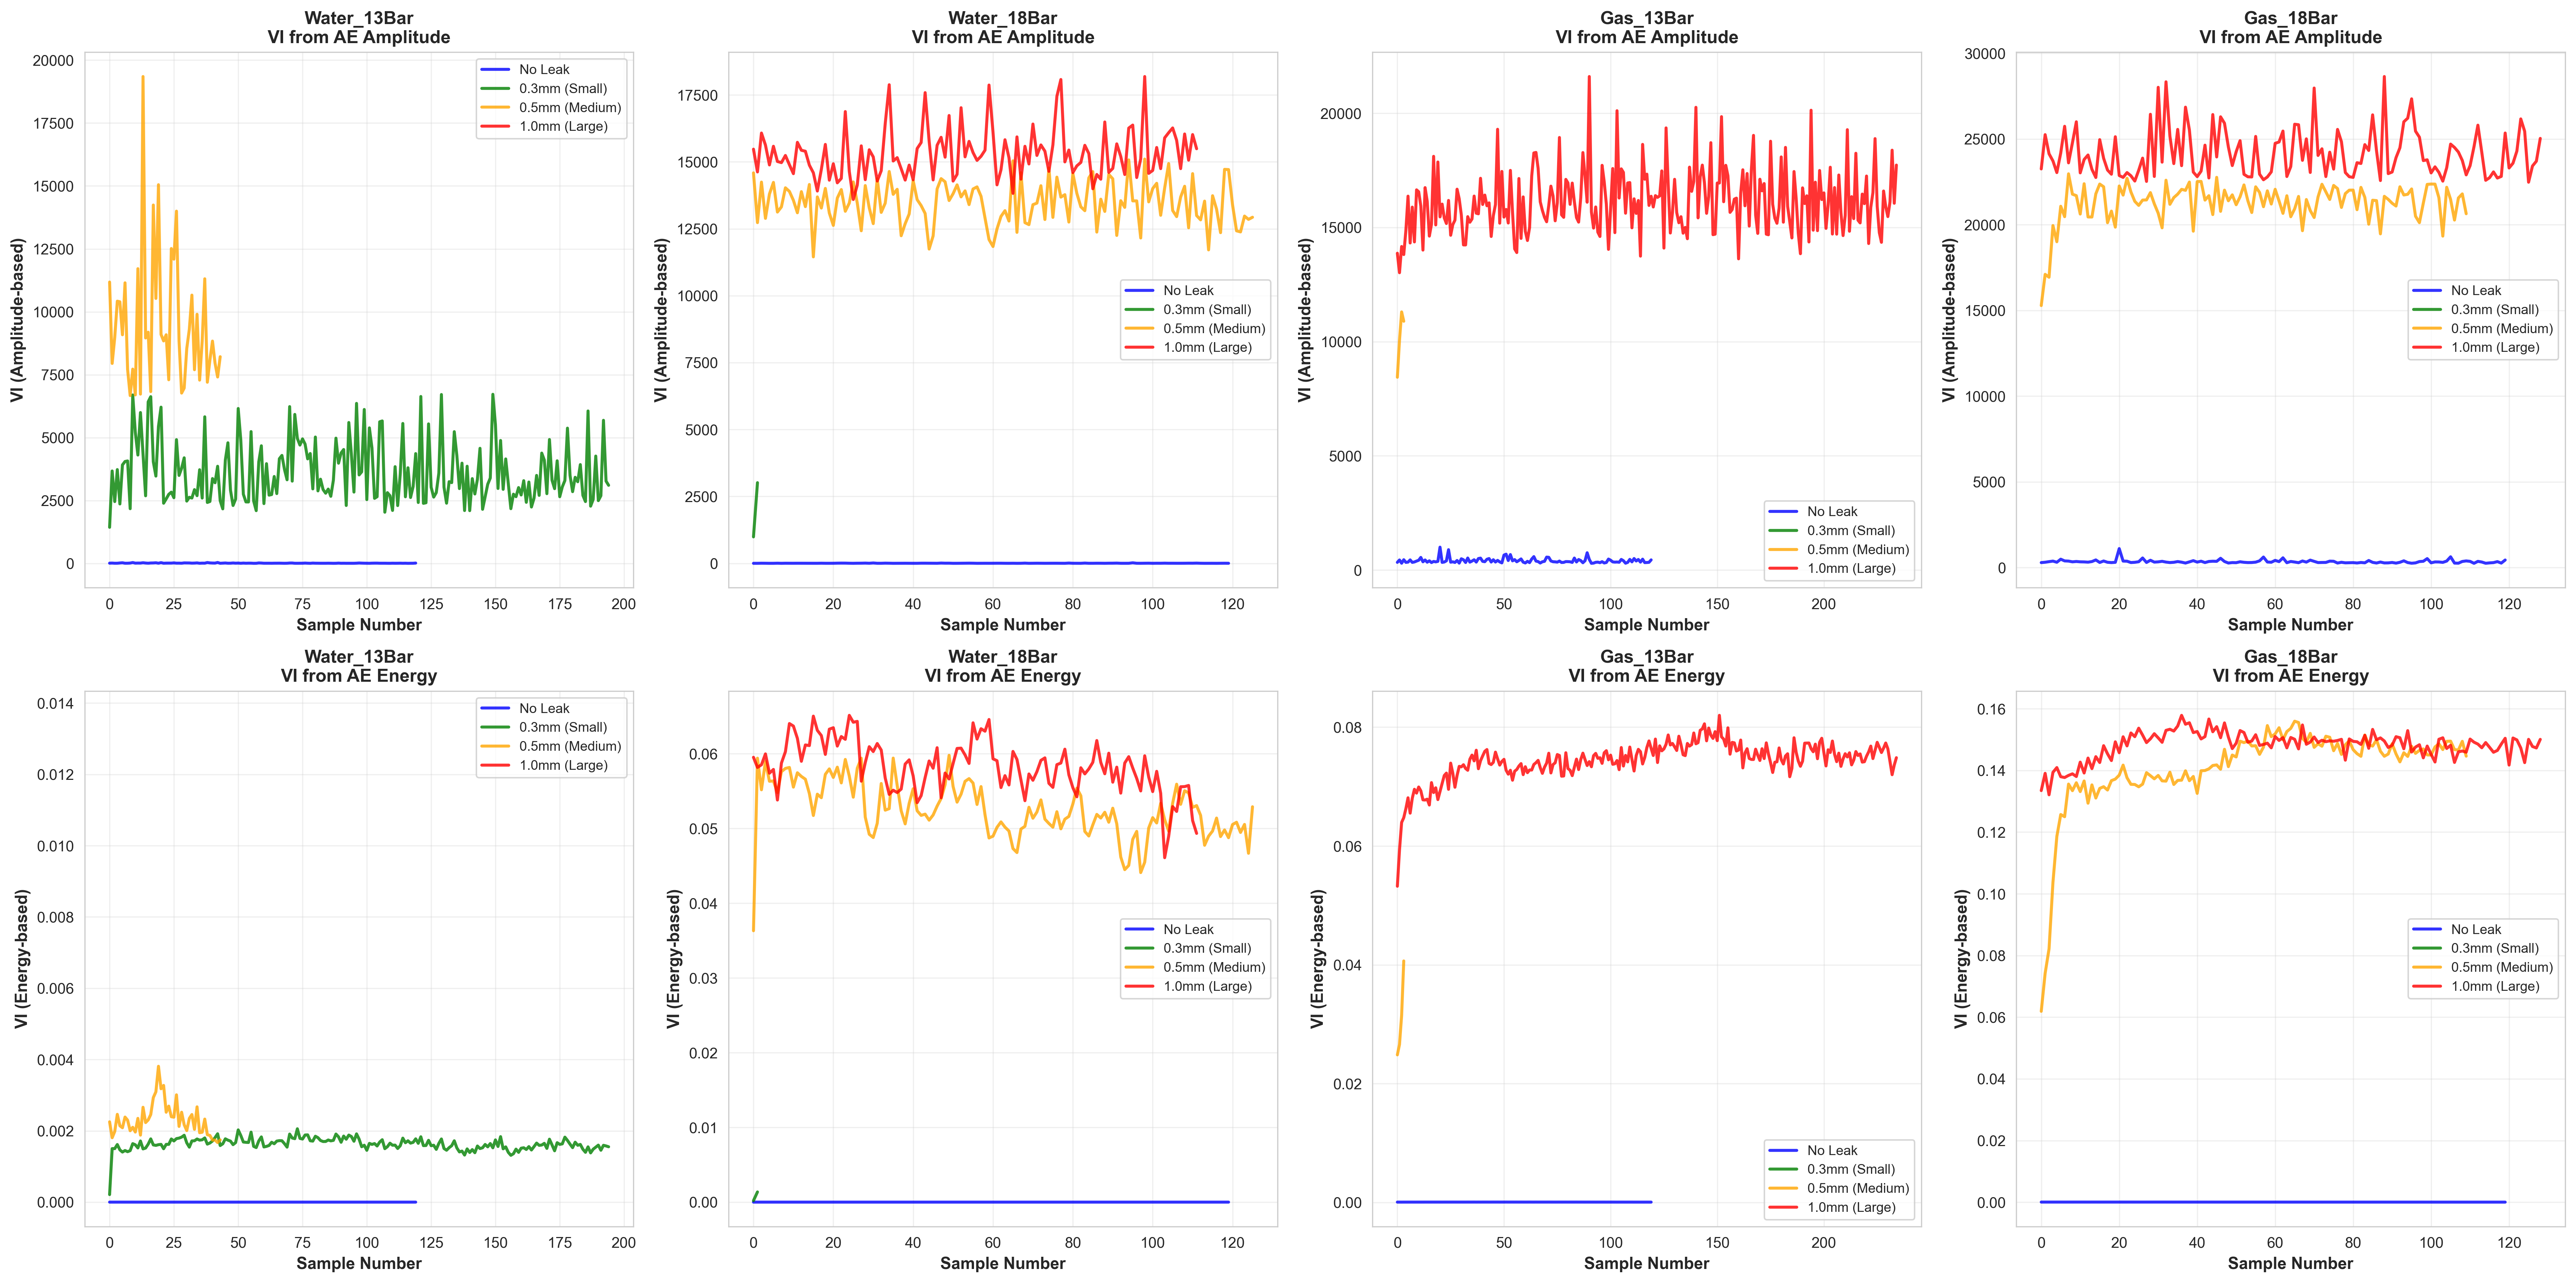

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load features
features_df = pd.read_csv('comprehensive_AE_features.csv')

# Separate leak and no-leak data
leak_data = features_df[features_df['label'] == 1].copy()
no_leak_data = features_df[features_df['label'] == 0].copy()

print("="*80)
print("LEAK SIZE CLUSTERING ANALYSIS")
print("="*80)

# Focus on amplitude-based features for leak characterization
amplitude_features = ['peak_amplitude', 'rms_amplitude', 'absolute_energy', 
                      'vulnerability_index_amplitude', 'ae_count']

for condition in ['Water_13Bar', 'Water_18Bar', 'Gas_13Bar', 'Gas_18Bar']:
    print(f"\n{'='*60}")
    print(f"Condition: {condition}")
    print(f"{'='*60}")
    
    # Get leak samples for this condition
    condition_leaks = leak_data[leak_data['condition'] == condition].copy()
    
    # Extract amplitude features
    X_cluster = condition_leaks[amplitude_features].values
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    # K-means clustering (assuming 3 leak sizes: 0.3mm, 0.5mm, 1mm)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    condition_leaks['leak_size_cluster'] = clusters
    
    # Analyze clusters
    print("\nCluster characteristics:")
    for cluster_id in range(3):
        cluster_samples = condition_leaks[condition_leaks['leak_size_cluster'] == cluster_id]
        print(f"\nCluster {cluster_id} (n={len(cluster_samples)}):")
        print(f"  Peak Amplitude: {cluster_samples['peak_amplitude'].mean():.4f} ± {cluster_samples['peak_amplitude'].std():.4f}")
        print(f"  RMS Amplitude:  {cluster_samples['rms_amplitude'].mean():.4f} ± {cluster_samples['rms_amplitude'].std():.4f}")
        print(f"  AE Count:       {cluster_samples['ae_count'].mean():.1f} ± {cluster_samples['ae_count'].std():.1f}")
        print(f"  Energy:         {cluster_samples['absolute_energy'].mean():.4f} ± {cluster_samples['absolute_energy'].std():.4f}")
    
    # Sort clusters by amplitude (small to large leak)
    cluster_means = []
    for cluster_id in range(3):
        cluster_samples = condition_leaks[condition_leaks['leak_size_cluster'] == cluster_id]
        cluster_means.append((cluster_id, cluster_samples['peak_amplitude'].mean()))
    
    cluster_means.sort(key=lambda x: x[1])
    
    # Map to leak sizes
    leak_size_map = {
        cluster_means[0][0]: '0.3mm (Small)',
        cluster_means[1][0]: '0.5mm (Medium)', 
        cluster_means[2][0]: '1.0mm (Large)'
    }
    
    condition_leaks['leak_size'] = condition_leaks['leak_size_cluster'].map(leak_size_map)
    
    print("\n\nMapped Leak Sizes:")
    print(condition_leaks['leak_size'].value_counts().sort_index())
    
    # Update the main dataframe
    leak_data.loc[leak_data['condition'] == condition, 'leak_size_cluster'] = condition_leaks['leak_size_cluster'].values
    leak_data.loc[leak_data['condition'] == condition, 'leak_size'] = condition_leaks['leak_size'].values

# Add leak size to no-leak data
no_leak_data['leak_size'] = 'No Leak'
no_leak_data['leak_size_cluster'] = -1

# Combine
full_data = pd.concat([leak_data, no_leak_data], ignore_index=True)

# Save
full_data.to_csv('AE_features_with_leak_sizes.csv', index=False)
print("\n✅ Saved: AE_features_with_leak_sizes.csv")

# Create Vulnerability Index plots like your reference image
def plot_vulnerability_index_curves(data):
    """
    Create VI plots similar to the reference image
    """
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    
    conditions = ['Water_13Bar', 'Water_18Bar', 'Gas_13Bar', 'Gas_18Bar']
    
    for col_idx, condition in enumerate(conditions):
        # Filter condition data
        cond_data = data[data['condition'] == condition].copy()
        cond_data = cond_data.sort_values('sample_idx')
        
        # Top row: VI from Amplitude
        ax1 = axes[0, col_idx]
        
        for leak_size in ['No Leak', '0.3mm (Small)', '0.5mm (Medium)', '1.0mm (Large)']:
            leak_samples = cond_data[cond_data['leak_size'] == leak_size]
            if len(leak_samples) > 0:
                # Calculate cumulative VI
                vi_amplitude = leak_samples['vulnerability_index_amplitude'].values
                sample_numbers = np.arange(len(vi_amplitude))
                
                # Plot
                if leak_size == 'No Leak':
                    ax1.plot(sample_numbers, vi_amplitude, label=leak_size, 
                            linewidth=2, alpha=0.8, color='blue')
                elif leak_size == '0.3mm (Small)':
                    ax1.plot(sample_numbers, vi_amplitude, label=leak_size,
                            linewidth=2, alpha=0.8, color='green')
                elif leak_size == '0.5mm (Medium)':
                    ax1.plot(sample_numbers, vi_amplitude, label=leak_size,
                            linewidth=2, alpha=0.8, color='orange')
                else:
                    ax1.plot(sample_numbers, vi_amplitude, label=leak_size,
                            linewidth=2, alpha=0.8, color='red')
        
        ax1.set_xlabel('Sample Number', fontsize=11, fontweight='bold')
        ax1.set_ylabel('VI (Amplitude-based)', fontsize=11, fontweight='bold')
        ax1.set_title(f'{condition}\nVI from AE Amplitude', fontsize=12, fontweight='bold')
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Bottom row: VI from Energy/Count
        ax2 = axes[1, col_idx]
        
        for leak_size in ['No Leak', '0.3mm (Small)', '0.5mm (Medium)', '1.0mm (Large)']:
            leak_samples = cond_data[cond_data['leak_size'] == leak_size]
            if len(leak_samples) > 0:
                vi_energy = leak_samples['vulnerability_index_energy'].values
                sample_numbers = np.arange(len(vi_energy))
                
                if leak_size == 'No Leak':
                    ax2.plot(sample_numbers, vi_energy, label=leak_size,
                            linewidth=2, alpha=0.8, color='blue')
                elif leak_size == '0.3mm (Small)':
                    ax2.plot(sample_numbers, vi_energy, label=leak_size,
                            linewidth=2, alpha=0.8, color='green')
                elif leak_size == '0.5mm (Medium)':
                    ax2.plot(sample_numbers, vi_energy, label=leak_size,
                            linewidth=2, alpha=0.8, color='orange')
                else:
                    ax2.plot(sample_numbers, vi_energy, label=leak_size,
                            linewidth=2, alpha=0.8, color='red')
        
        ax2.set_xlabel('Sample Number', fontsize=11, fontweight='bold')
        ax2.set_ylabel('VI (Energy-based)', fontsize=11, fontweight='bold')
        ax2.set_title(f'{condition}\nVI from AE Energy', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('vulnerability_index_analysis.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: vulnerability_index_analysis.png")
    plt.show()

print("\n🎨 Creating Vulnerability Index plots...")
plot_vulnerability_index_curves(full_data)